# 05 — EDA

Merges `eda-univariate-analysis`, `eda-multivariate-analysis` and
`data-visualization` (`PROJECT_PLAN.md` Section 3) into one narrated pass:
**univariate → bivariate → multivariate**, ending with the sector price map.

**Data table:** `data/processed/gurgaon_properties_missing_value_imputation.csv`
(3 554 × 18). It is the **last stage before feature selection ordinal-encodes
the categoricals into integer codes** — `post_feature_selection.csv` has
`property_type ∈ {0,1}`, `sector` as a fake-ordinal `0…103`, `agePossession ∈
{0…4}`, none of which can be read by eye. This table is fully imputed (zero
missing values, so no per-section "N missing" caveats) and keeps
`property_type` / `sector` / `agePossession` / `balcony` human-readable. Cost:
it dropped `super_built_up_area` / `carpet_area` / `facing` upstream, so the
areas section is just `built_up_area` (the one that feeds the model), and its
`price_per_sqft` is the **stale** copy carried from the missing-value stage —
flagged again on the one chart that uses it.

**Plots are matplotlib + pandas.** The three source notebooks are entirely
`seaborn`-based and none run against the current environment (seaborn isn't a
dependency here) or the current data: `sns.distplot` is removed from modern
seaborn, `sns.scatterplot(x_series, y_series)` positional args are gone, bare
`df.corr()` raises on the object columns, `sns.pairplot` on the full frame
errors, and the univariate observation text carries hard-coded numbers from an
older data snapshot. All charts are rebuilt and every number below is
regenerated from live output.

Per the project spec — *no visualisation without interpretation* — every chart
gets a written reading.

In [1]:
import sys, json
from pathlib import Path

REPO_ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import warnings
warnings.simplefilter("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.features.geo import sector_map_frame, build_sector_map, build_sector_map_static

plt.rcParams["figure.dpi"] = 100

df = pd.read_csv(REPO_ROOT / "data/processed/gurgaon_properties_missing_value_imputation.csv")
print("shape:", df.shape, " | missing values:", int(df.isnull().sum().sum()),
      " | exact duplicate rows:", int(df.duplicated().sum()))
df.head()


shape: (3554, 18)  | missing values: 0  | exact duplicate rows: 4


,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,signature global park 4,sector 36,0.82,7586.0,3.0,2.0,2,2.0,New Property,850.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0
1,flat,smart world gems,sector 89,0.95,8597.0,2.0,2.0,2,4.0,New Property,1226.0,1.0,1.0,0.0,0.0,0.0,0.0,38.0
2,flat,breez global hill view,sohna road,0.32,5470.0,2.0,2.0,1,17.0,New Property,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,49.0
3,flat,bestech park view sanskruti,sector 92,1.60,8020.0,3.0,4.0,3+,10.0,Relatively New,1615.0,0.0,1.0,0.0,0.0,1.0,1.0,174.0
4,flat,suncity avenue,sector 102,0.48,9023.0,2.0,2.0,1,5.0,Relatively New,582.0,0.0,0.0,1.0,0.0,0.0,0.0,159.0


## 1. Univariate

### 1.1 `price` (₹ crore)

count    3554.00
mean        2.44
std         2.78
min         0.07
25%         0.95
50%         1.51
75%         2.65
max        31.50

skewness 3.30   kurtosis 15.57
log1p:  skewness 1.07   kurtosis 1.03

IQR upper fence ₹5.20 Cr  ->  397 rows above it (11.2%)


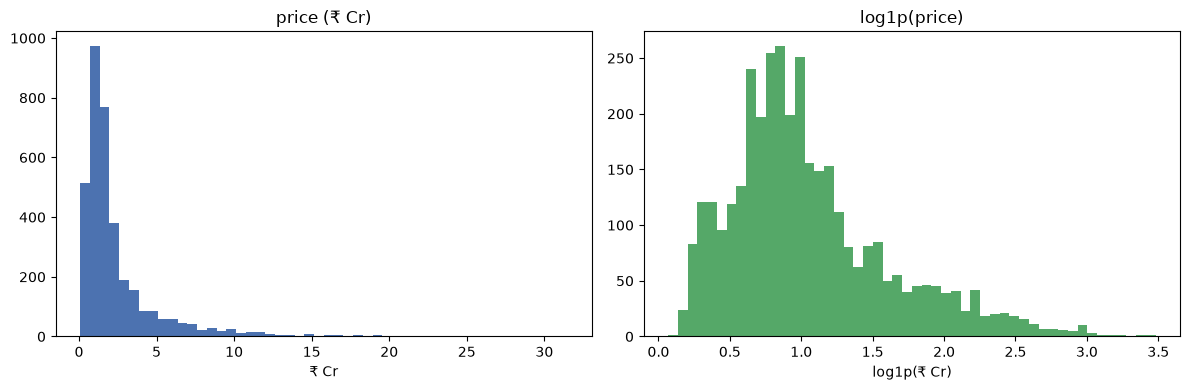

In [2]:
price = df["price"]
print(price.describe().round(2).to_string())
print(f"\nskewness {price.skew():.2f}   kurtosis {price.kurt():.2f}")
print(f"log1p:  skewness {np.log1p(price).skew():.2f}   kurtosis {np.log1p(price).kurt():.2f}")
q1, q3 = price.quantile(.25), price.quantile(.75)
fence = q3 + 1.5 * (q3 - q1)
print(f"\nIQR upper fence ₹{fence:.2f} Cr  ->  {int((price > fence).sum())} rows above it "
      f"({100 * (price > fence).mean():.1f}%)")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(price, bins=50, color="#4C72B0"); ax[0].set_title("price (₹ Cr)"); ax[0].set_xlabel("₹ Cr")
ax[1].hist(np.log1p(price), bins=50, color="#55A868"); ax[1].set_title("log1p(price)"); ax[1].set_xlabel("log1p(₹ Cr)")
plt.tight_layout(); plt.show()


Strongly right-skewed: mean ₹2.44 Cr sits well above the median ₹1.51 Cr, and
the raw distribution has skewness 3.3 / kurtosis 15.6 — a long thin tail of
₹10–31 Cr stock. `log1p` pulls skewness to ~1.1 and gives the near-symmetric
bell in the right panel; this is exactly why `src/models/train.py` fits on
`log1p(price)`. The IQR rule flags 397 rows (11 %) above ₹5.2 Cr, but price was
already IQR-treated in `04_outlier_detection` — these are genuine luxury
listings, not data errors, so no further trimming is done here.

price
0-1       963
1-2      1308
2-3       500
3-5       360
5-10      315
10-20     102
20-35       6


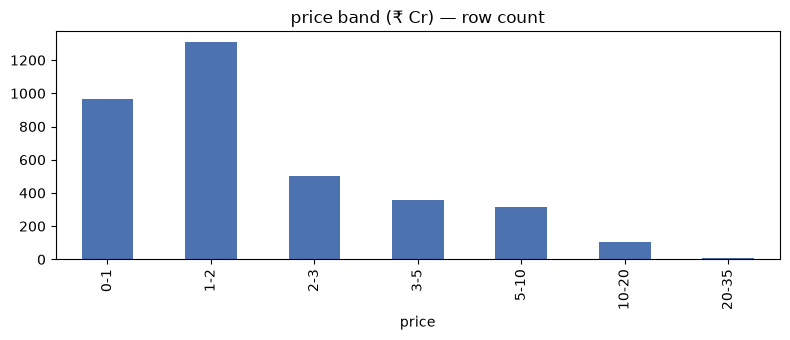

In [3]:
bins = [0, 1, 2, 3, 5, 10, 20, 35]
labels = ["0-1", "1-2", "2-3", "3-5", "5-10", "10-20", "20-35"]
banded = pd.cut(price, bins=bins, labels=labels, right=False).value_counts().sort_index()
print(banded.to_string())
banded.plot(kind="bar", color="#4C72B0", figsize=(8, 3.5), title="price band (₹ Cr) — row count")
plt.tight_layout(); plt.show()


Half the market is between ₹1 Cr and ₹3 Cr. Volume falls off a cliff above
₹5 Cr (the ₹5-10 band already holds fewer rows than ₹0-1), and the ₹10 Cr+
segment is a few hundred rows total.

### 1.2 `built_up_area` (sq ft)

count     3554.0
mean      1862.0
std       1216.0
min         33.0
25%       1202.0
50%       1614.0
75%       2200.0
max      12222.0

largest values: [12222.0, 11286.0, 11111.0, 11111.0, 11111.0, 10000.0]
rows > 20,000 sqft: 0


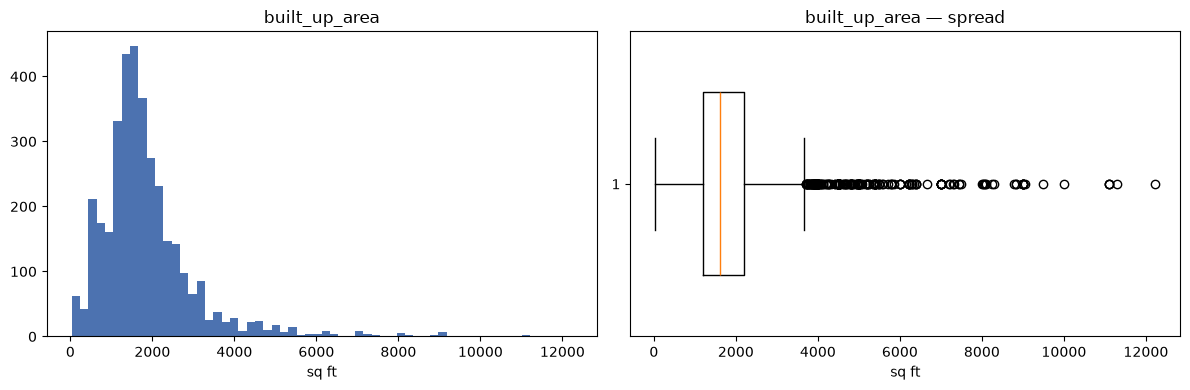

In [4]:
bua = df["built_up_area"]
print(bua.describe().round(0).to_string())
print(f"\nlargest values: {sorted(bua.nlargest(6).tolist(), reverse=True)}")
print(f"rows > 20,000 sqft: {int((bua > 20000).sum())}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(bua, bins=60, color="#4C72B0"); ax[0].set_title("built_up_area"); ax[0].set_xlabel("sq ft")
ax[1].boxplot(bua, vert=False, widths=0.6); ax[1].set_title("built_up_area — spread"); ax[1].set_xlabel("sq ft")
plt.tight_layout(); plt.show()


Median 1 614 sq ft, right-skewed, tapering smoothly to a max of 12 222 sq ft with only 5 rows above 10 000 and **none above 20 000**.

There is one 737 147 sq ft artifact in the *raw*-side data (society `hcbs sports ville`, sohna road; the scraped `areaWithType` string is literally `Built Up area: 737147`). It does not reach this table, and two separate things are worth keeping straight about it:

1. **The original `eda-multivariate-analysis.ipynb` deletes it by hand.** Cell 10 is `# removing that crazy outlier` / `df = df[df['built_up_area'] != 737147]` — a one-off filter on that exact value. It has to, because that notebook reads `gurgaon_properties_cleaned_v2.csv`, where the row is still present.
2. **The actual pipeline removes it earlier, for an unrelated general reason.** Traced by identity (society + sector + price + bedRoom + floor), the row is in `cleaned_v2` and gone from `outlier_treated.csv` onward. What drops it is `outliers.py`'s generic threshold filter `df = df[df['area'] < 100_000]`: the same listing also carries `area = 875000`, which trips the cap, so the whole row is filtered out at the outlier stage. Nothing targets `737147` or even looks at `built_up_area` — and the later missing-value rules could not have touched it anyway (ratio fill acts only on nulls, the small-area override only on values `< 2000`).

The hand-written notebook fix was **never ported into `src/`, correctly** — it is redundant on every table downstream of `outliers.py`, since the general `area < 100_000` rule already removes the row.

### 1.3 `bedRoom` and `bathroom`

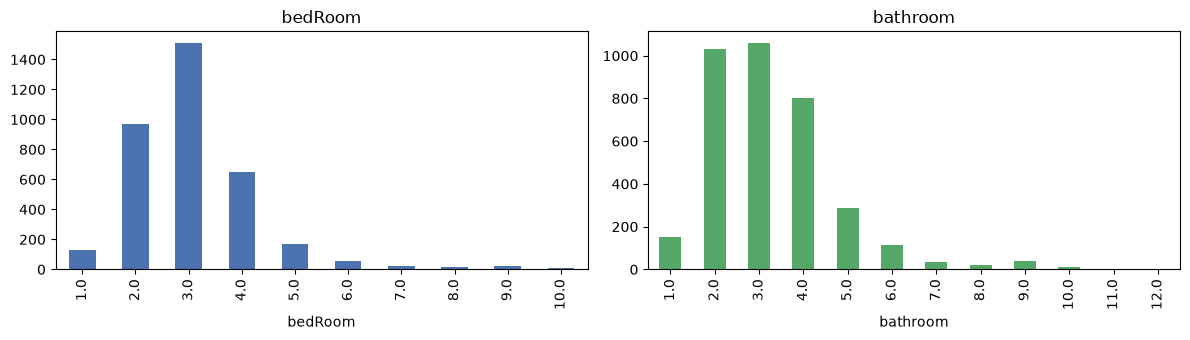

bedRoom : {1.0: 127, 2.0: 969, 3.0: 1512, 4.0: 647, 5.0: 171, 6.0: 53, 7.0: 20, 8.0: 18, 9.0: 25, 10.0: 12}
bathroom: {1.0: 150, 2.0: 1032, 3.0: 1061, 4.0: 804, 5.0: 285, 6.0: 116, 7.0: 36, 8.0: 19, 9.0: 39, 10.0: 9, 11.0: 2, 12.0: 1}


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
df["bedRoom"].value_counts().sort_index().plot(kind="bar", ax=ax[0], color="#4C72B0", title="bedRoom")
df["bathroom"].value_counts().sort_index().plot(kind="bar", ax=ax[1], color="#55A868", title="bathroom")
plt.tight_layout(); plt.show()
print("bedRoom :", df["bedRoom"].value_counts().sort_index().to_dict())
print("bathroom:", df["bathroom"].value_counts().sort_index().to_dict())


3 BHK is the mode (1 512 rows), then 2 BHK (969) and 4 BHK (647) — the bulk of
the market is 2–4 bedrooms. Everything from 7 BHK up is a thin tail (~75 rows
total), almost all independent houses. Bathroom count tracks bedrooms closely,
peaking at 2–3, with the same long tail.

### 1.4 `property_type`, `furnishing_type`, `balcony`

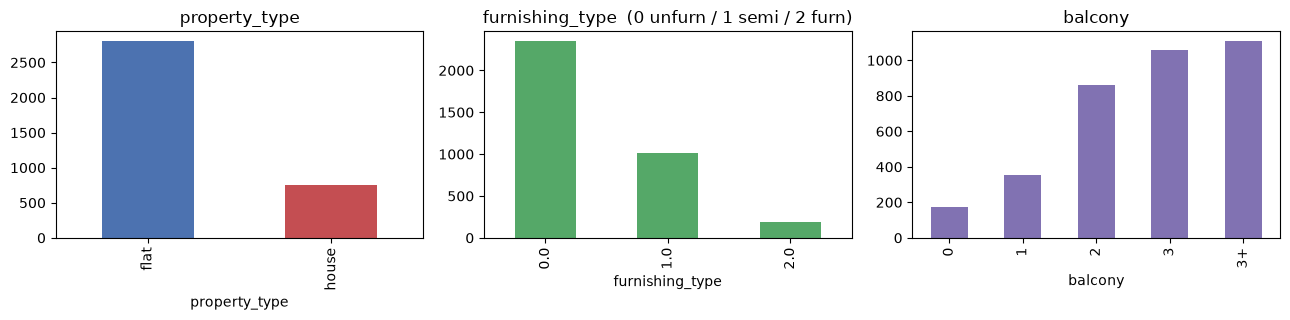

property_type  : {'flat': 0.789, 'house': 0.211}
furnishing_type: {0.0: 0.661, 1.0: 0.286, 2.0: 0.053}


In [6]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.3))
df["property_type"].value_counts().plot(kind="bar", ax=ax[0], color=["#4C72B0", "#C44E52"], title="property_type")
df["furnishing_type"].value_counts().sort_index().plot(kind="bar", ax=ax[1], color="#55A868",
    title="furnishing_type  (0 unfurn / 1 semi / 2 furn)")
df["balcony"].value_counts().reindex(["0", "1", "2", "3", "3+"]).plot(kind="bar", ax=ax[2], color="#8172B2", title="balcony")
plt.tight_layout(); plt.show()
print("property_type  :", df["property_type"].value_counts(normalize=True).round(3).to_dict())
print("furnishing_type:", df["furnishing_type"].value_counts(normalize=True).round(3).to_dict())


**property_type** — 79 % flats, 21 % houses. **furnishing_type** — 66 %
unfurnished, 29 % semi-furnished, only 5 % fully furnished; a model feature that
is heavily one-sided. **balcony** — skewed high: 61 % of listings report 3 or
"3+" balconies, which is more a quirk of how 99acres captures the field than a
real signal.

### 1.5 `luxury_score` and `agePossession`

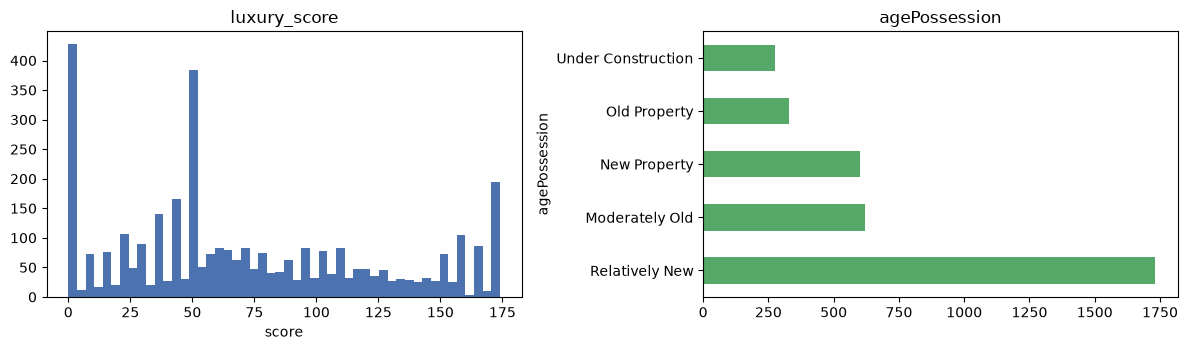

luxury_score: mean 72  median 60  exactly 0: 428 rows   > 100: 1070 rows


In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].hist(df["luxury_score"], bins=50, color="#4C72B0"); ax[0].set_title("luxury_score"); ax[0].set_xlabel("score")
df["agePossession"].value_counts().plot(kind="barh", ax=ax[1], color="#55A868", title="agePossession")
plt.tight_layout(); plt.show()
print(f"luxury_score: mean {df['luxury_score'].mean():.0f}  median {df['luxury_score'].median():.0f}  "
      f"exactly 0: {int((df['luxury_score'] == 0).sum())} rows   > 100: {int((df['luxury_score'] > 100).sum())} rows")


**luxury_score** is bimodal: a spike of 428 rows at exactly 0 (listings whose
amenity list didn't parse / wasn't backfilled from `appartments.csv`), then a
broad hump centred ~90–120. Median 60. The 0-spike matters — it means "unknown",
not "no amenities". **agePossession** — nearly half the listings are "Relatively
New" (1 732); "Old Property" is the smallest real category (327).

### 1.6 `sector` (location)

104 unique sectors
frequency bands:  >100: 3  | 50-100: 23  | 10-49: 60  | 2-9: 18  | 1: 0


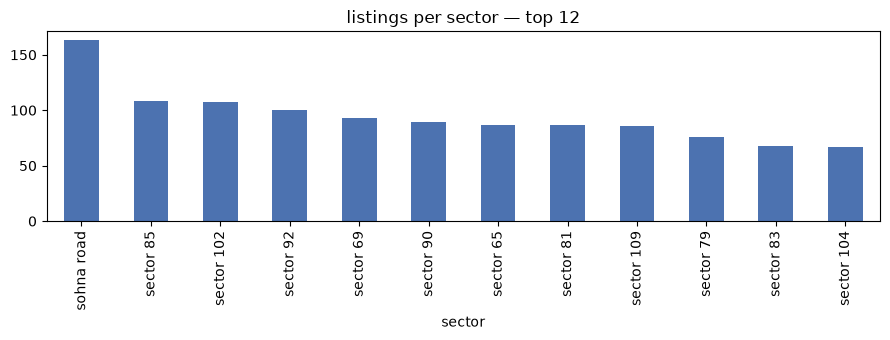

In [8]:
sc = df["sector"].value_counts()
print(f"{df['sector'].nunique()} unique sectors")
print("frequency bands:  >100:", int((sc > 100).sum()),
      " | 50-100:", int(((sc >= 50) & (sc <= 100)).sum()),
      " | 10-49:", int(((sc >= 10) & (sc < 50)).sum()),
      " | 2-9:", int(((sc > 1) & (sc < 10)).sum()),
      " | 1:", int((sc == 1).sum()))
sc.head(12).plot(kind="bar", color="#4C72B0", figsize=(9, 3.5), title="listings per sector — top 12")
plt.tight_layout(); plt.show()


104 sectors, none with a single listing — coverage is reasonably even. The
biggest bucket is `sohna road` (163 rows), a road name rather than a numbered
sector; then the New Gurgaon sectors 85 / 102 / 92 (~100 each). 26 sectors carry
50+ listings and account for most of the data; the other ~78 have 10–49 each.

## 2. Bivariate

### 2.1 `price` vs `built_up_area` (coloured by `bedRoom`)

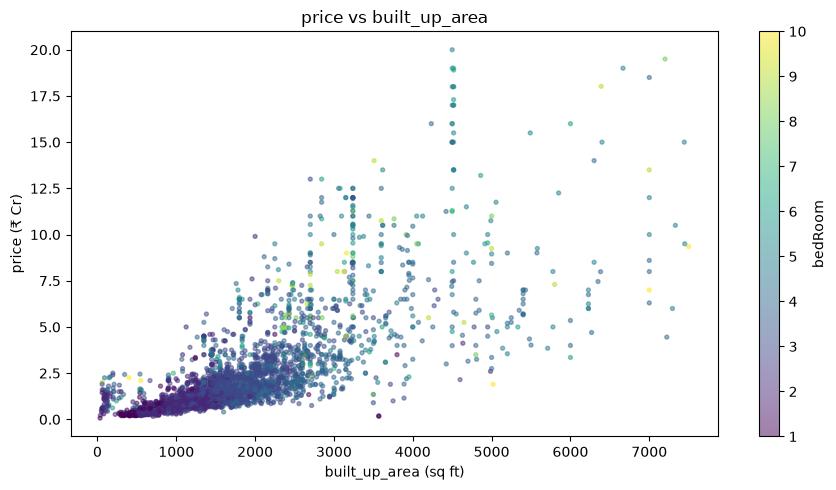

Pearson r(price, built_up_area) = 0.749


In [9]:
sub = df[df["built_up_area"] < 8000]
scat = plt.scatter(sub["built_up_area"], sub["price"], c=sub["bedRoom"], cmap="viridis", s=8, alpha=0.5)
plt.colorbar(scat, label="bedRoom"); plt.xlabel("built_up_area (sq ft)"); plt.ylabel("price (₹ Cr)")
plt.title("price vs built_up_area"); plt.gcf().set_size_inches(9, 5); plt.tight_layout(); plt.show()
print("Pearson r(price, built_up_area) =", round(df["price"].corr(df["built_up_area"]), 3))


Clear positive relationship (r = 0.75), but the cloud **fans out** with size:
at 1 000 sq ft prices sit in a tight ₹0.5–1.5 Cr band, while at 3 000 sq ft they
run anywhere from ₹2 Cr to ₹15 Cr. Area sets a floor; sector and configuration
decide where in the range a property lands. The colour gradient confirms
bedroom count rises with area but doesn't add much beyond it.

### 2.2 `price` and `built_up_area` vs `bedRoom`

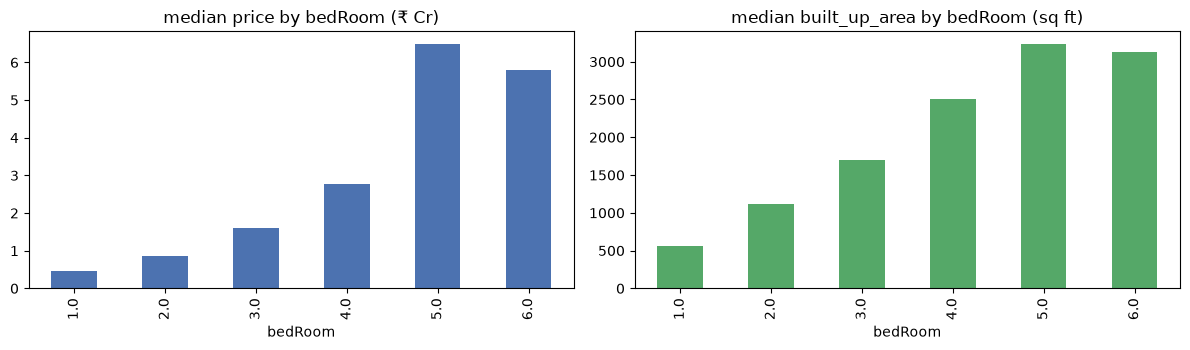

median price   : {1.0: 0.45, 2.0: 0.85, 3.0: 1.6, 4.0: 2.78, 5.0: 6.5, 6.0: 5.8}
median area    : {1.0: 565.0, 2.0: 1120.0, 3.0: 1700.0, 4.0: 2500.0, 5.0: 3240.0, 6.0: 3132.0}


In [10]:
g = df[df["bedRoom"] <= 6].groupby("bedRoom")
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
g["price"].median().plot(kind="bar", ax=ax[0], color="#4C72B0", title="median price by bedRoom (₹ Cr)")
g["built_up_area"].median().plot(kind="bar", ax=ax[1], color="#55A868", title="median built_up_area by bedRoom (sq ft)")
plt.tight_layout(); plt.show()
print("median price   :", g["price"].median().round(2).to_dict())
print("median area    :", g["built_up_area"].median().round(0).to_dict())


Both rise monotonically 1→5 BHK — median price ₹0.45 → 0.85 → 1.60 → 2.78 →
6.5 Cr, median area 565 → 1 120 → 1 700 → 2 500 → 3 240 sq ft (roughly
+600–800 sq ft per bedroom). The 6 BHK bar dips on both (₹5.8 Cr, 3 130 sq ft):
only 53 rows, and 6 BHK+ mixes genuine mansions with subdivided or mislabelled
stock — a pattern also seen in `PROJECT_PLAN.md` Section 11's `property_type`
issue.

### 2.3 `price` by `property_type` and by `agePossession`

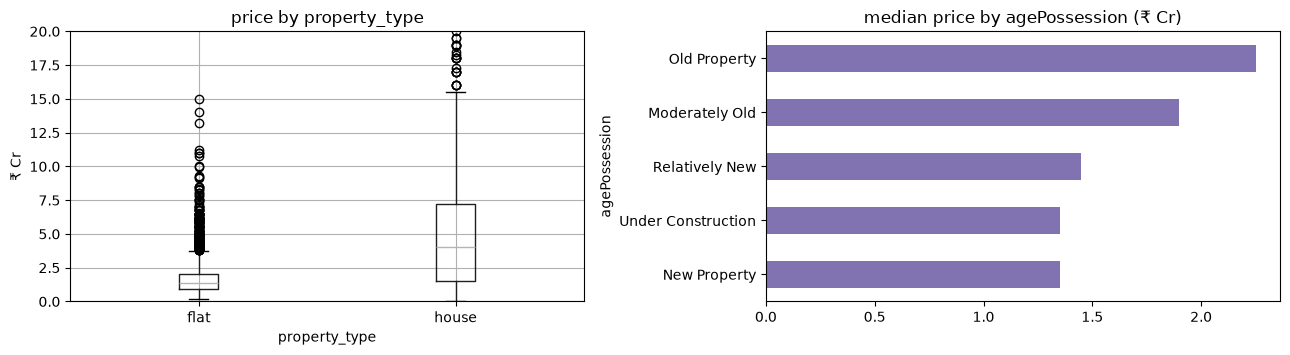

median price by property_type: {'flat': 1.39, 'house': 4.04}
median price by agePossession: {'Moderately Old': 1.9, 'New Property': 1.35, 'Old Property': 2.25, 'Relatively New': 1.45, 'Under Construction': 1.35}


In [11]:
fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
df.boxplot(column="price", by="property_type", ax=ax[0])
ax[0].set_title("price by property_type"); ax[0].set_ylabel("₹ Cr"); ax[0].set_ylim(0, 20)
df.groupby("agePossession")["price"].median().sort_values().plot(kind="barh", ax=ax[1], color="#8172B2",
    title="median price by agePossession (₹ Cr)")
plt.suptitle(""); plt.tight_layout(); plt.show()
print("median price by property_type:", df.groupby("property_type")["price"].median().round(2).to_dict())
print("median price by agePossession:", df.groupby("agePossession")["price"].median().round(2).to_dict())


**property_type** — house median ₹4.04 Cr vs flat ₹1.39 Cr, roughly 3×: houses
here are plots/villas carrying land value, and they dominate the upper tail.
**agePossession** — counter-intuitively "Old Property" has the highest median
(₹2.25 Cr) and "New"/"Under Construction" the lowest (₹1.35 Cr). Age isn't
making old homes expensive; old stock is concentrated in the established central
sectors (DLF phases, Golf Course Road) where land is dear, while new supply is
mostly peripheral New Gurgaon.

### 2.4 `price_per_sqft` by `sector`

> **Caveat — stale `price_per_sqft`.** This column is the copy carried from the
> missing-value stage; it was **not** recomputed after `built_up_area` was
> imputed there (a documented weak spot of that stage). Treat the absolute
> ₹/sq ft values as indicative only. The **sector ordering** below is robust
> (it also matches the independently-built sector map in section 3.4); the exact
> numbers are not.

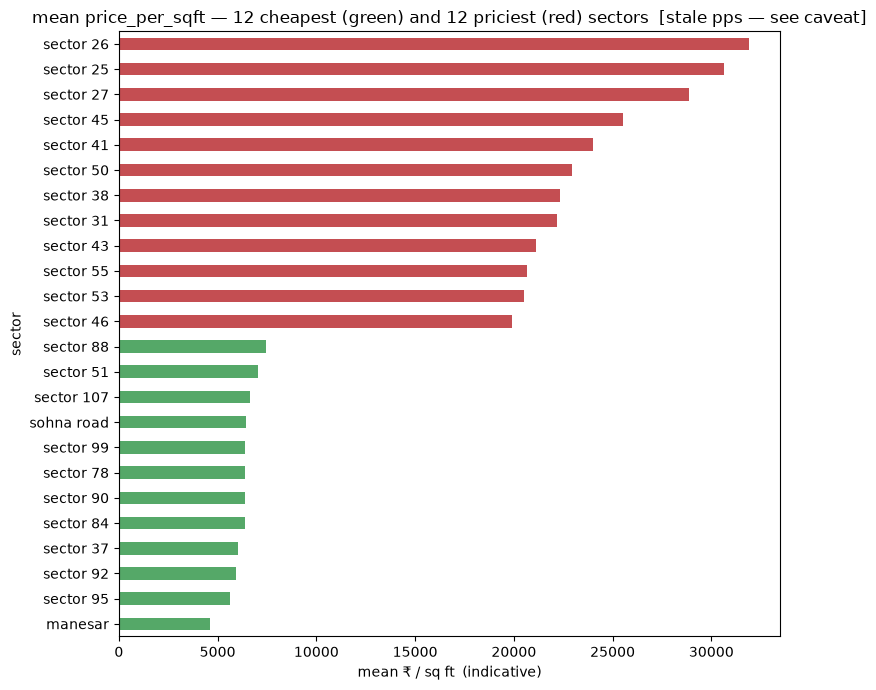

cheapest: {'manesar': 4608.0, 'sector 95': 5603.0, 'sector 92': 5928.0, 'sector 37': 6033.0, 'sector 84': 6375.0}
priciest: {'sector 41': 24011.0, 'sector 45': 25526.0, 'sector 27': 28890.0, 'sector 25': 30650.0, 'sector 26': 31882.0}


In [12]:
pps = df.groupby("sector")["price_per_sqft"].mean().sort_values()
ends = pd.concat([pps.head(12), pps.tail(12)])
ends.plot(kind="barh", figsize=(8, 7), color=["#55A868"] * 12 + ["#C44E52"] * 12,
          title="mean price_per_sqft — 12 cheapest (green) and 12 priciest (red) sectors  [stale pps — see caveat]")
plt.xlabel("mean ₹ / sq ft  (indicative)"); plt.tight_layout(); plt.show()
print("cheapest:", pps.head(5).round(0).to_dict())
print("priciest:", pps.tail(5).round(0).to_dict())


A 5–7× spread across sectors. The cheap end is New Gurgaon / Dwarka Expressway
(Manesar ~₹4.6k, sectors 95 / 92 / 37 / 84 ~₹5.6–6.4k); the expensive end is the
Golf Course Road corridor (sectors 26 / 25 / 27 / 45 / 41 ~₹24k–32k). Location
is the single largest lever on unit price — the model picks this up too, where
`sector` is the #2 feature after `built_up_area`.

## 3. Multivariate

### 3.1 Correlation with `price`

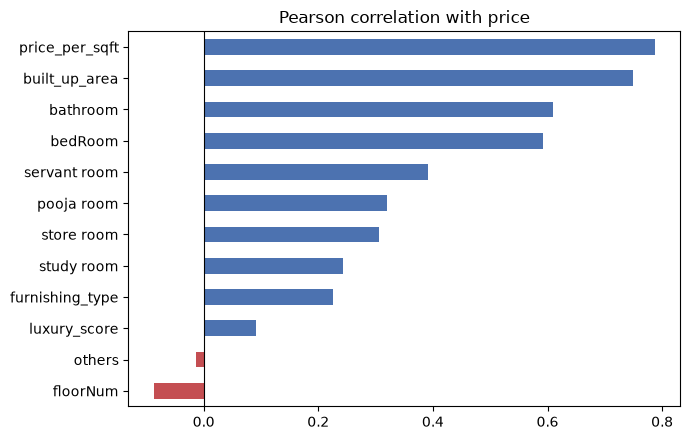

price_per_sqft     0.787
built_up_area      0.749
bathroom           0.610
bedRoom            0.591
servant room       0.392
pooja room         0.320
store room         0.306
study room         0.243
furnishing_type    0.226
luxury_score       0.091
others            -0.013
floorNum          -0.087


In [13]:
corr = df.corr(numeric_only=True)["price"].drop("price").sort_values()
corr.plot(kind="barh", figsize=(7, 4.5), color=["#C44E52" if v < 0 else "#4C72B0" for v in corr],
          title="Pearson correlation with price")
plt.axvline(0, color="k", lw=0.8); plt.tight_layout(); plt.show()
print(corr.sort_values(ascending=False).round(3).to_string())


`price_per_sqft` (0.79) is mechanical — it's price ÷ area. The real drivers are
`built_up_area` (0.75), `bathroom` (0.61) and `bedRoom` (0.59). Three things
stand out:

- **`luxury_score` correlates only 0.09 with price** — near nothing. This lines
  up with `reports/model/explainability_summary.md`, where `luxury_category`
  contributes almost nothing to the model's prediction.
- **`floorNum` is weakly *negative* (−0.09)** — the counter-intuitive finding
  flagged in `PROJECT_PLAN.md` Section 3. Higher-floor listings skew toward
  cheaper New Gurgaon high-rises; "floor 0-1" includes ground-floor independent
  houses in expensive central sectors.
- The additional-room flags (`servant room` 0.39, `pooja room` 0.32) correlate
  better with price than `furnishing_type` (0.23) does — they proxy for size and
  segment.

### 3.2 Numeric correlation matrix

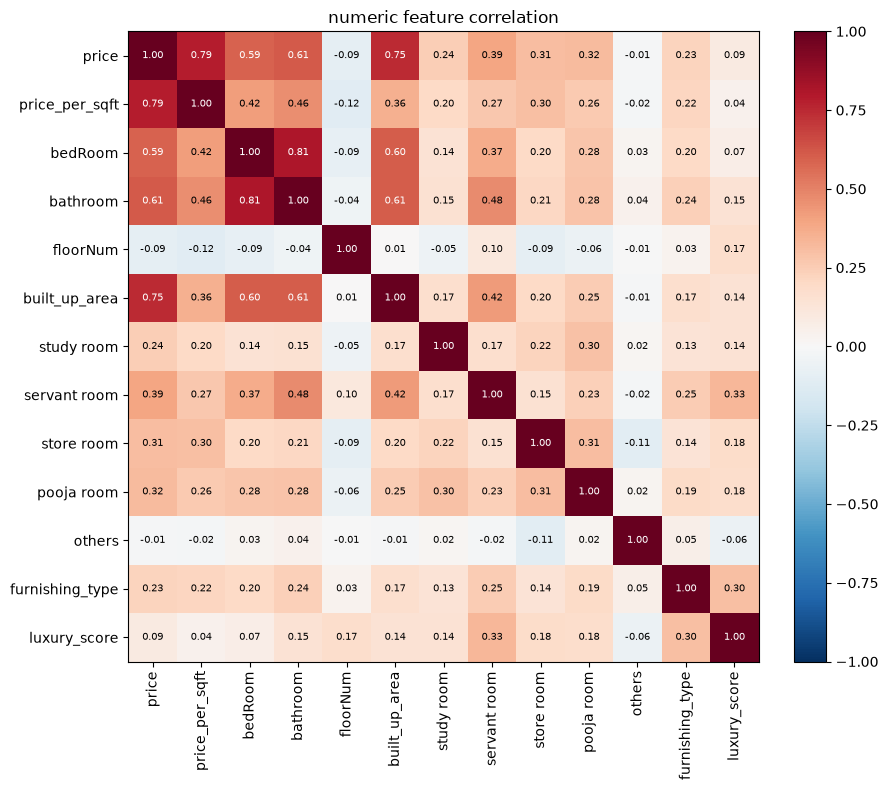

In [14]:
num = df.select_dtypes("number")
M = num.corr()
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(M, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(M))); ax.set_xticklabels(M.columns, rotation=90)
ax.set_yticks(range(len(M))); ax.set_yticklabels(M.columns)
for i in range(len(M)):
    for j in range(len(M)):
        ax.text(j, i, f"{M.iloc[i, j]:.2f}", ha="center", va="center",
                color="white" if abs(M.iloc[i, j]) > 0.55 else "black", fontsize=7)
fig.colorbar(im, fraction=0.046); plt.title("numeric feature correlation"); plt.tight_layout(); plt.show()


The strongest off-diagonal block is `bedRoom` / `bathroom` / `built_up_area`
(0.7–0.85 among themselves) — one underlying "size" factor, which is why the
feature-selection notebook found dropping a few room columns costs nothing.
`floorNum` is essentially uncorrelated with everything except a mild negative to
the size cluster. `luxury_score` correlates more with the size features
(~0.3–0.4) than with `price` (0.09) — bigger homes list more amenities, but that
doesn't translate into price here.

### 3.3 `property_type` × `agePossession` and × `bedRoom` — mean price

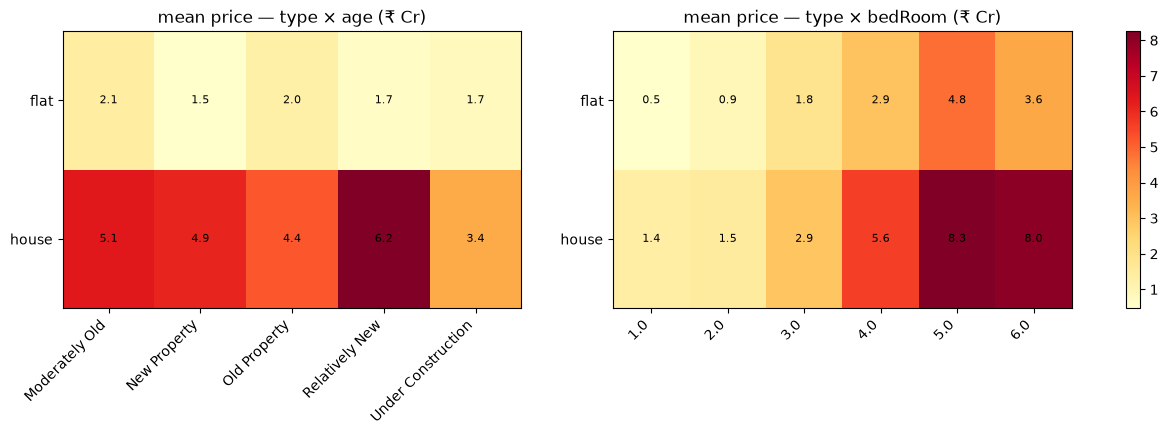

In [15]:
def pivot_heat(index, columns, ax, title):
    P = df.pivot_table(index=index, columns=columns, values="price", aggfunc="mean")
    im = ax.imshow(P, cmap="YlOrRd", aspect="auto")
    ax.set_xticks(range(P.shape[1])); ax.set_xticklabels(P.columns, rotation=45, ha="right")
    ax.set_yticks(range(P.shape[0])); ax.set_yticklabels(P.index)
    for i in range(P.shape[0]):
        for j in range(P.shape[1]):
            v = P.iloc[i, j]
            if pd.notna(v):
                ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=8)
    ax.set_title(title); return im

fig, ax = plt.subplots(1, 2, figsize=(14, 3.6))
pivot_heat("property_type", "agePossession", ax[0], "mean price — type × age (₹ Cr)")
im = pivot_heat("property_type", df["bedRoom"].where(df["bedRoom"] <= 6), ax[1], "mean price — type × bedRoom (₹ Cr)")
fig.colorbar(im, ax=ax, fraction=0.02); plt.show()


Houses sit above flats in every cell — property type dominates the interaction.
Within flats, mean price climbs steadily with bedroom count and is roughly flat
across age categories (the age effect from section 2.3 is really a location
effect). The house row is noisier because of the small, high-variance 5–6 BHK
counts.

### 3.4 Location patterns — the sector price map

The bivariate `price_per_sqft`-by-sector bars in section 2.4 said the money is
in a contiguous eastern corridor. The map makes that geographic. It is built by
`src/features/geo.py` from `data/raw/latlong.csv` joined onto this same table —
a **bubble map** (one bubble per sector centroid, coloured by mean
`price_per_sqft`, sized by mean `built_up_area`), not filled polygons, because
no GeoJSON of informal Gurgaon sector boundaries exists (Section 4).

In [16]:
group_df, report = sector_map_frame()   # also writes data/processed/sector_price_map.csv
print(json.dumps(report, indent=2, default=str))


{
  "n_input_rows": 3554,
  "n_joined_rows": 3383,
  "n_dropped_rows": 171,
  "n_sectors_input": 104,
  "n_exact_matches": 101,
  "n_fallback_matches": 1,
  "fallback_matches": {
    "sector 70a": "sector 70"
  },
  "unmatched_sectors": [
    "dwarka expressway",
    "sohna road"
  ],
  "dropped_rows_by_sector": {
    "dwarka expressway": 8,
    "sohna road": 163
  },
  "sector_frame_csv": "data\\processed\\sector_price_map.csv"
}


**Reading the join report:** 3 383 / 3 554 rows join. `sector 70a` is recovered
by the trailing-letter fallback. Two sectors stay unmatched because they are
*road* names, not suffix variants: `sohna road` (163 rows, ~4.6 % — the one
material loss) and `dwarka expressway` (8 rows). `latlong.csv` carries 129
sectors vs 104 in the data, so ~27 coordinate rows go unused — expected superset
slack.

In [17]:
group_df.sort_values("price_per_sqft", ascending=False).head(10)


,price,price_per_sqft,built_up_area,latitude,longitude,n_properties
sector,,,,,,
sector 26,11.81,31881.85,4026.10,28.48,77.10,40
sector 25,8.66,30650.00,3395.85,28.48,77.09,37
sector 27,6.12,28889.50,2196.00,28.47,77.09,2
sector 45,8.50,25525.50,2897.50,28.45,77.07,8
sector 41,6.14,24010.73,2971.82,28.46,77.06,11
sector 50,6.74,22964.82,3097.56,28.42,77.06,61
sector 38,3.89,22355.60,2056.30,28.43,77.04,10
sector 31,3.53,22197.30,1572.30,28.45,77.05,10
sector 43,5.86,21125.59,2470.22,28.46,77.08,58


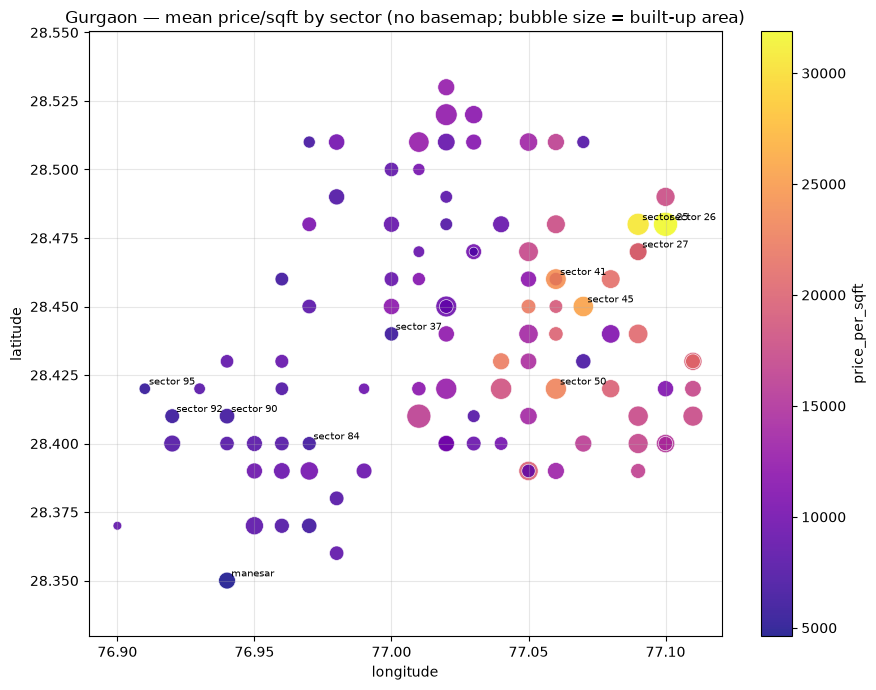

In [18]:
static_fig = build_sector_map_static(group_df)   # matplotlib; embeds in any viewer


**Reading the map.** Price per sq ft falls off sharply east→west. The bright
band — sectors 24–28 and 41–54 plus the DLF phases — is the Golf Course Road /
Golf Course Extension corridor (~₹22k–32k/sq ft). The dark western cluster —
sectors 90 / 92 / 95 and Manesar — is New Gurgaon along the Dwarka Expressway
belt (~₹4.6k–6k/sq ft). Bubble size (built-up area) is largest in the
low-density eastern luxury sectors. Same ordering as the section 2.4 bars, now
placed on the ground.

`build_sector_map()` returns the interactive Plotly OpenStreetMap version for a
live kernel or the app; it renders blank in Jupyter inline output specifically
(verified — see `src/features/geo.py`), so the committed embedded figure is the
matplotlib one above.

In [19]:
fig = build_sector_map(group_df)
print(f"{type(fig).__name__}: {len(fig.data[0].lat)} sector bubbles "
      "(call fig.show() in a live kernel, or use it in the app).")


Figure: 102 sector bubbles (call fig.show() in a live kernel, or use it in the app).
